**TASK 7: Get Basic Sales Summary from a Tiny SQLite Database using Python**

In [ ]:
# Import the libraries
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

**Create SQLite Database**

In [ ]:
# Create SQLite Database
conn =  sqlite3.connect("sales_db.db")
cursor = conn.cursor()

**Create Sales Table**

In [ ]:
# Create Sales Table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales(
Id INT PRIMARY KEY,
Product TEXT,
Quantity INT,
Price REAL)
""")

**Insert Sample Data**

In [ ]:
data = [
    (101, 'Laptop', 5, 50000.00),
    (102, 'Speaker', 20, 4000.00),
    (103, 'Tablet', 10, 16000.00),
    (104, 'Airpods', 50, 2000.00),
    (105, 'Bluetooth Neckband', 10, 700.00),
    (106, 'Projector', 2,10000.00),
    (107, 'Mouse', 50, 1500.00),
    (108, 'Keyboard', 30, 2000.00),
    (109, 'Power Bank', 10, 1500.00),
    (110, 'Ipad', 2, 100000.00)
]

cursor.executemany("INSERT INTO sales VALUES(?,?,?,?)",data)
conn.commit()

**Fetch the data**

In [ ]:
# Fetch the data
cursor.execute("select * from sales")
values = cursor.fetchall()
for value in values:
  print(value)

(101, 'Laptop', 5, 50000.0)
(102, 'Speaker', 20, 4000.0)
(103, 'Tablet', 10, 16000.0)
(104, 'Airpods', 50, 2000.0)
(105, 'Bluetooth Neckband', 10, 700.0)
(106, 'Projector', 2, 10000.0)
(107, 'Mouse', 50, 1500.0)
(108, 'Keyboard', 30, 2000.0)
(109, 'Power Bank', 10, 1500.0)
(110, 'Ipad', 2, 100000.0)


**SQL query to calculate total quantity and revenue**

In [ ]:
# SQL query to calculate total quantity and revenue
query = """
SELECT Product as 'Product_Name',
SUM(Quantity) as 'Total_Sales',
SUM(Quantity * Price) as 'Revenue'
FROM sales
GROUP BY Product
ORDER BY Revenue DESC
"""

cursor.execute(query)
values = cursor.fetchall()
for value in values:
  print(value)

('Laptop', 5, 250000.0)
('Ipad', 2, 200000.0)
('Tablet', 10, 160000.0)
('Airpods', 50, 100000.0)
('Speaker', 20, 80000.0)
('Mouse', 50, 75000.0)
('Keyboard', 30, 60000.0)
('Projector', 2, 20000.0)
('Power Bank', 10, 15000.0)
('Bluetooth Neckband', 10, 7000.0)


**Load the SQL query results into a Pandas DataFrame and Print the result**

In [ ]:
# Load the SQL query results into a Pandas DataFrame and Print the result
data = pd.read_sql_query(query, conn)
data

,Product_Name,Total_Sales,Revenue
0,Laptop,5,250000.0
1,Ipad,2,200000.0
2,Tablet,10,160000.0
3,Airpods,50,100000.0
4,Speaker,20,80000.0
5,Mouse,50,75000.0
6,Keyboard,30,60000.0
7,Projector,2,20000.0
8,Power Bank,10,15000.0
9,Bluetooth Neckband,10,7000.0


**Plot a simple bar chart**

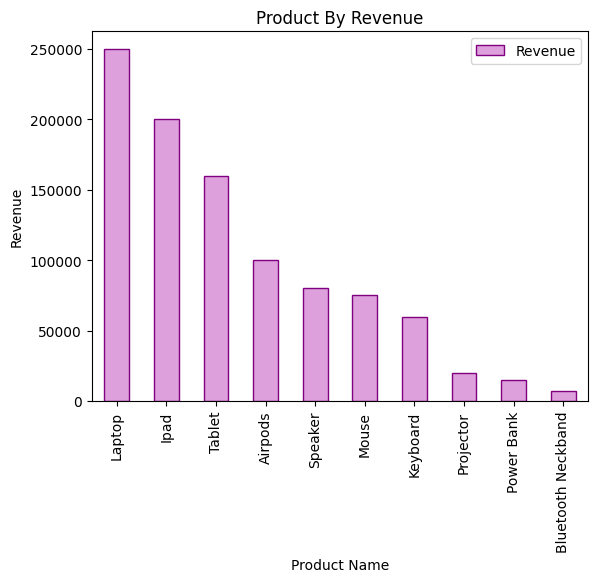

In [ ]:
# Plot a simple bar chart
data.plot(kind = 'bar',
        x='Product_Name', y='Revenue',
          color='Plum', edgecolor='purple')
plt.title('Product By Revenue')
plt.xlabel('Product Name')
plt.ylabel('Revenue')
plt.show()

**Save the chart**

In [46]:
# Save the chart
plt.savefig('Product by Revenue Chart.png')

conn.close()

<Figure size 640x480 with 0 Axes>